## Problem Definition

Heart disease can be difficult to identify early without medical testing. ECG images contain important information about the heart's electrical activity.

The objective of this project is to build a neural network model that can classify ECG images into different heart condition classes.

The model will take an ECG image as input and predict the correct class.

## Dataset Selection

The dataset used in this project is the **ECG Image Dataset** from Kaggle.

The dataset contains ECG images divided into 4 classes:

1. Myocardial Infarction
2. History of MI
3. Abnormal Heartbeat
4. Normal
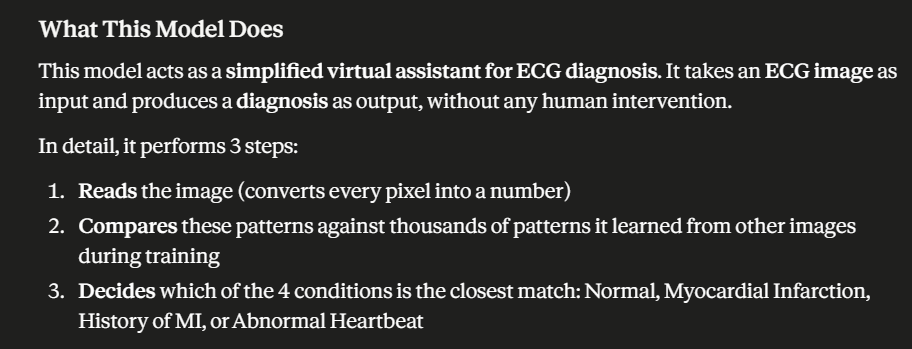
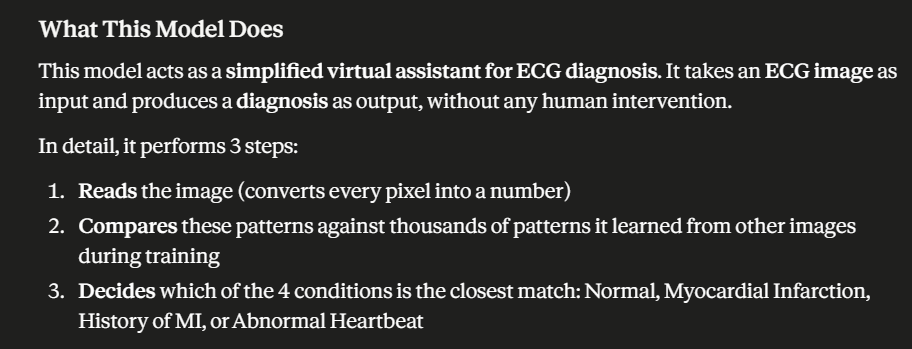

In [1]:
# Import libraries and set random seed
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import pandas as pd
import random
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [2]:
#Dataset paths
train_path = "/kaggle/input/datasets/kanishkarathore1604/ecg-image/ECG_DATA/train"
test_path = "/kaggle/input/datasets/kanishkarathore1604/ecg-image/ECG_DATA/test"

In [3]:
#Load images from folders
img_size = (128, 128)
batch_size = 32

train_data = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical',
    seed=seed
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical',
    seed=seed
)

Found 3023 files belonging to 4 classes.


I0000 00:00:1782997307.497837      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 928 files belonging to 4 classes.


In [4]:
#Class names
class_names = [
    "Myocardial Infarction",
    "History of MI",
    "Abnormal Heartbeat",
    "Normal"
]
print(class_names)

['Myocardial Infarction', 'History of MI', 'Abnormal Heartbeat', 'Normal']


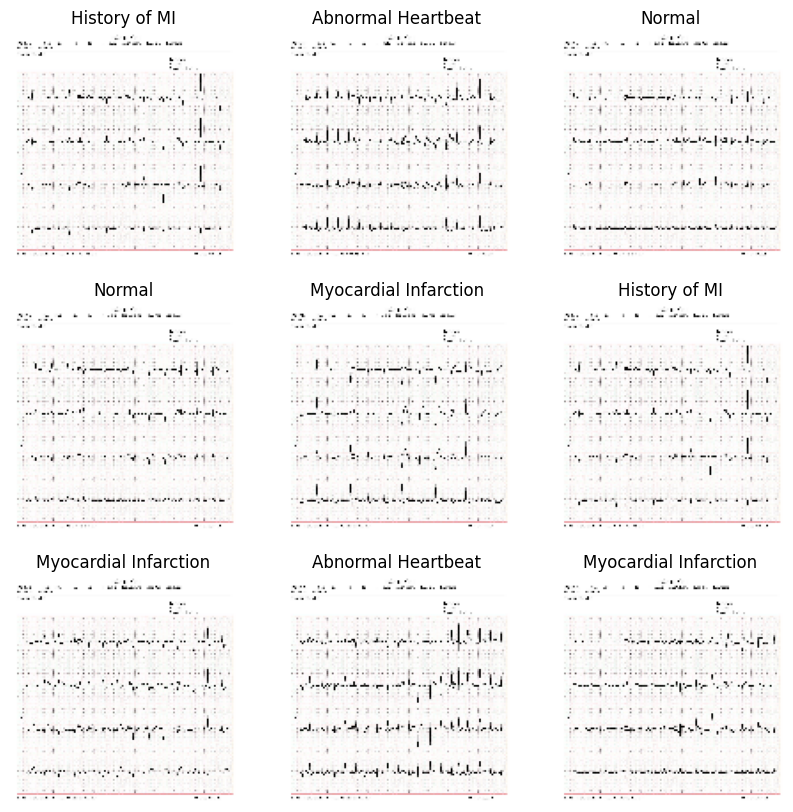

In [5]:
#Show Sample Images
plt.figure(figsize=(10, 10))
for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis("off")
plt.show()

In [6]:
#Class Distribution Table
train_counts = np.zeros(len(class_names))
test_counts = np.zeros(len(class_names))

for images, labels in train_data:
    train_counts += labels.numpy().sum(axis=0)

for images, labels in test_data:
    test_counts += labels.numpy().sum(axis=0)

class_distribution = pd.DataFrame({
    "Class": class_names,
    "Training Images": train_counts.astype(int),
    "Testing Images": test_counts.astype(int)
})

class_distribution["Total Images"] = class_distribution["Training Images"] + class_distribution["Testing Images"]
class_distribution

,Class,Training Images,Testing Images,Total Images
0,Myocardial Infarction,956,239,1195
1,History of MI,516,172,688
2,Abnormal Heartbeat,699,233,932
3,Normal,852,284,1136


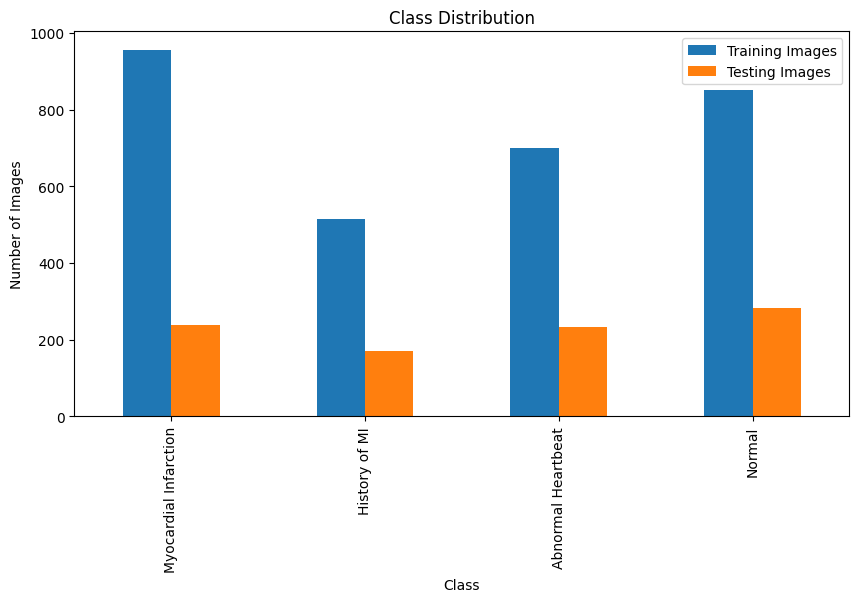

In [7]:
#Class Distribution Bar Chart
class_distribution.plot(
    x="Class",
    y=["Training Images", "Testing Images"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [8]:
#Normalize pixel values
train_data = train_data.map(lambda x, y: (x / 255, y))
test_data = test_data.map(lambda x, y: (x / 255, y))

In [9]:
#Build the MLP model
deep_model = Sequential([
    Flatten(input_shape=(128, 128, 3)),

    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),

    Dense(4, activation="softmax")
])

deep_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,583,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,624,580 (48.16 MB)

 Trainable params: 12,624,580 (48.16 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
#Compile the model
deep_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
#Train the model
history = deep_model.fit(
    train_data,
    epochs=13,
    validation_data=test_data
)

Epoch 1/13
 1/95 ━━━━━━━━━━━━━━━━━━━━ 4:50 3s/step - accuracy: 0.1250 - loss: 1.7195

I0000 00:00:1782997347.266949      72 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


95/95 ━━━━━━━━━━━━━━━━━━━━ 31s 293ms/step - accuracy: 0.2875 - loss: 6.1720 - val_accuracy: 0.3060 - val_loss: 2.0811
Epoch 2/13
95/95 ━━━━━━━━━━━━━━━━━━━━ 23s 247ms/step - accuracy: 0.3983 - loss: 1.4643 - val_accuracy: 0.2705 - val_loss: 1.5146
Epoch 3/13
95/95 ━━━━━━━━━━━━━━━━━━━━ 23s 245ms/step - accuracy: 0.4267 - loss: 1.3206 - val_accuracy: 0.6153 - val_loss: 1.0150
Epoch 4/13
95/95 ━━━━━━━━━━━━━━━━━━━━ 23s 244ms/step - accuracy: 0.4892 - loss: 1.1897 - val_accuracy: 0.3082 - val_loss: 1.3641
Epoch 5/13
95/95 ━━━━━━━━━━━━━━━━━━━━ 28s 293ms/step - accuracy: 0.5805 - loss: 1.0394 - val_accuracy: 0.6509 - val_loss: 0.9917
Epoch 6/13
95/95 ━━━━━━━━━━━━━━━━━━━━ 23s 243ms/step - accuracy: 0.6649 - loss: 0.8778 - val_accuracy: 0.5744 - val_loss: 0.8928
Epoch 7/13
95/95 ━━━━━━━━━━━━━━━━━━━━ 23s 244ms/step - accuracy: 0.5518 - loss: 1.1067 - val_accuracy: 0.4946 - val_loss: 2.0822
Epoch 8/13
95/95 ━━━━━━━━━━━━━━━━━━━━ 23s 244ms/step - accuracy: 0.6828 - loss: 0.8697 - val_accuracy: 0.612

In [12]:
#Evaluate the model
test_loss, test_accuracy = deep_model.evaluate(test_data)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 189ms/step - accuracy: 0.8750 - loss: 0.3773
Test Loss: 0.37727367877960205
Test Accuracy: 0.875


29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 180ms/step


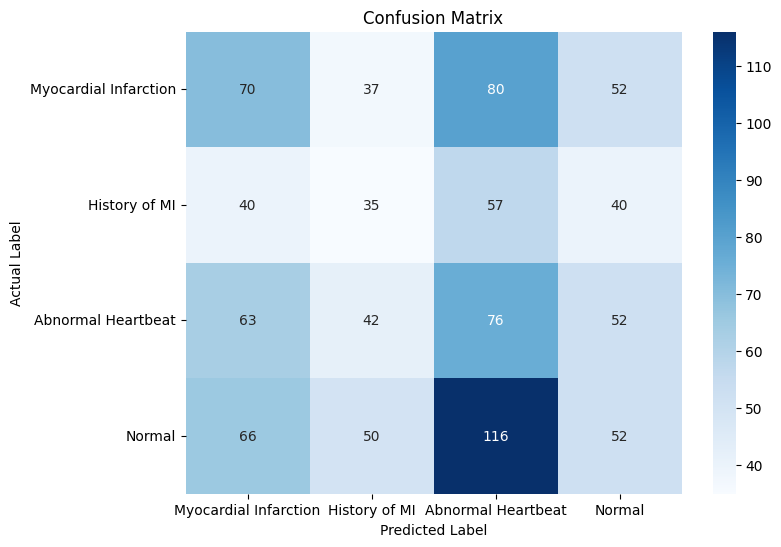

                       precision    recall  f1-score   support

Myocardial Infarction       0.29      0.29      0.29       239
        History of MI       0.21      0.20      0.21       172
   Abnormal Heartbeat       0.23      0.33      0.27       233
               Normal       0.27      0.18      0.22       284

             accuracy                           0.25       928
            macro avg       0.25      0.25      0.25       928
         weighted avg       0.25      0.25      0.25       928



In [13]:
y_pred_probs = deep_model.predict(test_data)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = np.concatenate([y for x, y in test_data], axis=0)
y_true = np.argmax(y_true, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Myocardial Infarction", "History of MI", "Abnormal Heartbeat", "Normal"],
            yticklabels=["Myocardial Infarction", "History of MI", "Abnormal Heartbeat", "Normal"])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print(classification_report(y_true, y_pred, target_names=["Myocardial Infarction", "History of MI", "Abnormal Heartbeat", "Normal"]))

In [14]:
#Classification Report (Precision, Recall, F1-score)
y_true = []
y_pred = []

for images, labels in test_data:
    predictions = deep_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
pd.DataFrame(report_dict).transpose().round(2)

,precision,recall,f1-score,support
Myocardial Infarction,1.00,1.00,1.00,239.00
History of MI,0.94,0.90,0.92,172.00
Abnormal Heartbeat,0.69,0.97,0.81,233.00
Normal,0.98,0.68,0.80,284.00
accuracy,0.88,0.88,0.88,0.88
macro avg,0.90,0.89,0.88,928.00
weighted avg,0.90,0.88,0.88,928.00


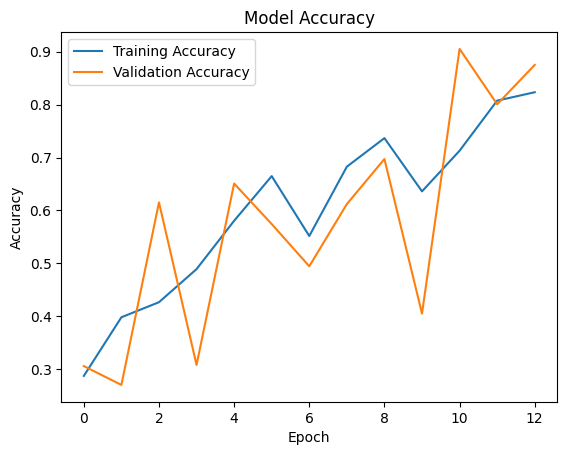

In [15]:
#Plot Accuracy curve
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.show()

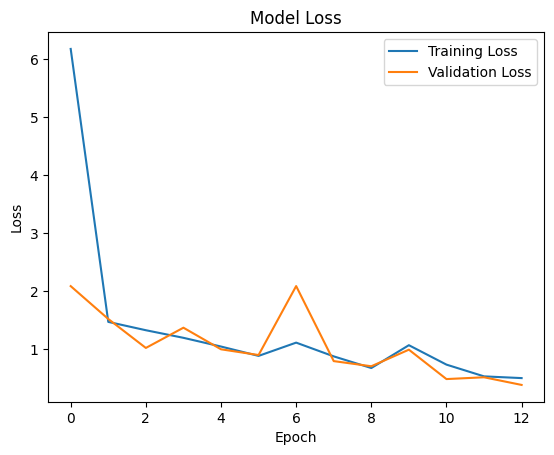

In [16]:
#Plot Loss curve
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])
plt.show()

In [17]:
#Save the trained model
deep_model.save("ecg_mlp_model.keras")

## Classification Report

We evaluated the model's performance in more detail using **Precision**, **Recall**, and **F1-score** for each class individually.

This is important because the dataset is not perfectly balanced across the 4 classes, so overall accuracy alone can hide weaknesses in specific classes.

- **Precision**: how many of the images the model labeled as a certain class were actually correct.
- **Recall**: how many of the actual images of a certain class the model successfully identified.
- **F1-score**: a balance between precision and recall.



## Evaluation Summary

The model was evaluated using Test Accuracy and Test Loss.

Test Accuracy shows how many ECG images were classified correctly.

Test Loss shows the error of the model's predictions.

The accuracy and loss graphs show how the model's performance changed during training.

We also used a Classification Report to check Precision, Recall, and F1-score for each class individually. This helps us see if the model performs equally well across all 4 classes, or if it struggles with specific ones due to the imbalance in the dataset.